In [20]:
import pandas as pd

property = pd.read_csv("../data/datasets/property.csv")
rent = pd.read_csv("../data/datasets/rent.csv")

# Filtering only "Indiana"
property_in = property[property["State"]=="IN"]
rent_in = rent[rent["State"]=="IN"]

print(property_in.head)
print(rent_in.shape)

<bound method NDFrame.head of        RegionID  SizeRank  RegionName RegionType StateName State  \
194       78085       200       46307        zip        IN    IN   
212       78823       218       47906        zip        IN    IN   
585       78042       595       46227        zip        IN    IN   
814       77986       826       46143        zip        IN    IN   
891       77918       904       46032        zip        IN    IN   
...         ...       ...         ...        ...       ...   ...   
26237     78122     39992       46379        zip        IN    IN   
26250     78335     39992       46915        zip        IN    IN   
26285     78519     39992       47282        zip        IN    IN   
26294     78282     39992       46799        zip        IN    IN   
26298     78367     39992       46958        zip        IN    IN   

                 City                               Metro         CountyName  \
194       Crown Point  Chicago-Naperville-Elgin, IL-IN-WI        Lake Cou

In [3]:
# clean the dataset [zip, price], [zip, rent]
latest_price = property_in.columns[-1]
latest_rent = rent_in.columns[-1]

property_clean = property_in[["RegionName", latest_price]]
rent_clean = rent_in[["RegionName", latest_rent]]

property_clean.columns = ["zip", "price"]
rent_clean.columns = ["zip", "rent"]

In [4]:
# merge two dataset by zip
df = pd.merge(property_clean, rent_clean, on='zip')
# change data type of zip from float to str
df["zip"] = df["zip"].astype(str)
df

,zip,price,rent
0,46307,344780.210739,1717.277778
1,47906,352889.508856,1887.579088
2,46227,221105.296376,1266.475783
3,46143,326074.864400,1601.971500
4,46032,556863.332620,1691.869929
...,...,...,...
146,46225,165506.169165,1484.533333
147,46616,137867.565807,1333.015873
148,47901,251723.716611,1176.836538
149,47305,75547.923859,765.416667


In [5]:
# calcualte ROI
df["ROI"] = (df["rent"]*12) / df["price"]
df

,zip,price,rent,ROI
0,46307,344780.210739,1717.277778,0.059769
1,47906,352889.508856,1887.579088,0.064187
2,46227,221105.296376,1266.475783,0.068735
3,46143,326074.864400,1601.971500,0.058955
4,46032,556863.332620,1691.869929,0.036459
...,...,...,...,...
146,46225,165506.169165,1484.533333,0.107636
147,46616,137867.565807,1333.015873,0.116026
148,47901,251723.716611,1176.836538,0.056101
149,47305,75547.923859,765.416667,0.121578


In [22]:
income = pd.read_csv("../data/datasets/income.csv")

# Clear median income data [zip, median_income]
income = income.iloc[1:]
income = income[["NAME", "B19013_001E"]]
income.columns = ["zip", "median_income"]
income["zip"] = income["zip"].str[-5:]
income_in = income[income["zip"].isin(df["zip"])]

income

,zip,median_income
1,00601,19454
2,00602,21420
3,00603,20933
4,00606,20992
5,00610,24496
...,...,...
33768,99923,-
33769,99925,61250
33770,99926,72279
33771,99927,-


In [7]:
# [zip, price, rent, ROI, median_price]
investment_df = pd.merge(df, income, on="zip", how="left")
investment_df

,zip,price,rent,ROI,median_income
0,46307,344780.210739,1717.277778,0.059769,107800
1,47906,352889.508856,1887.579088,0.064187,53103
2,46227,221105.296376,1266.475783,0.068735,53629
3,46143,326074.864400,1601.971500,0.058955,91496
4,46032,556863.332620,1691.869929,0.036459,132085
...,...,...,...,...,...
146,46225,165506.169165,1484.533333,0.107636,55190
147,46616,137867.565807,1333.015873,0.116026,58537
148,47901,251723.716611,1176.836538,0.056101,47206
149,47305,75547.923859,765.416667,0.121578,36389


In [8]:
# highest income
investment_df.sort_values("median_income", ascending=False).head()

,zip,price,rent,ROI,median_income
126,46184,263574.443240,1673.333333,0.076183,99865
14,46385,358640.520546,1666.111111,0.055748,98957
128,47111,296550.825992,1317.555556,0.053315,95376
121,46064,326629.808694,1985.000000,0.072927,94609
38,47630,310081.074047,1337.611111,0.051765,94162


In [9]:
# highest ROI
investment_df.sort_values("ROI", ascending=False).head()

,zip,price,rent,ROI,median_income
143,46409,80460.594930,1320.000000,0.196867,44667
118,46404,87709.867445,1385.000000,0.189488,42256
127,46408,100487.518300,1263.333333,0.150865,47453
138,47713,90787.605704,1102.805556,0.145765,40873
113,46016,79494.998185,947.678571,0.143055,36029


zip                  str
price            float64
rent             float64
ROI              float64
median_income        str
dtype: object

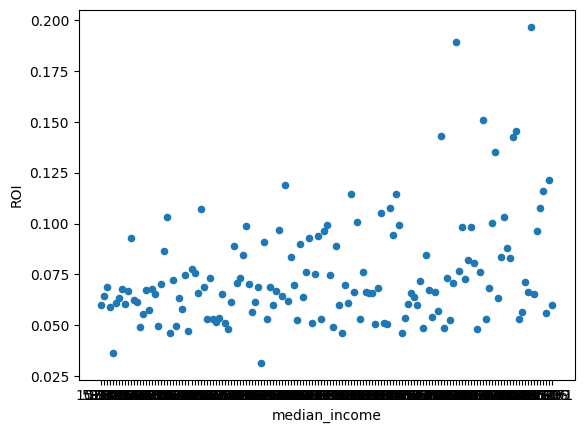

In [10]:
# Relation ROI vs income
investment_df.plot.scatter(x="median_income", y="ROI")
investment_df.dtypes

In [11]:
investment_df["median_income"] = pd.to_numeric(investment_df["median_income"])
investment_df[
    (investment_df["ROI"] > 0.08) &
    (investment_df["median_income"] > 50000)
].sort_values("ROI", ascending=False)


,zip,price,rent,ROI,median_income
147,46616,137867.565807,1333.015873,0.116026,58537
96,46323,177791.572846,1597.722222,0.107838,59688
146,46225,165506.169165,1484.533333,0.107636,55190
33,46222,125041.151410,1119.001709,0.107389,50783
93,46324,174391.353679,1526.250000,0.105022,63052
134,46405,145053.823300,1250.000000,0.103410,60881
22,46203,160455.849971,1378.555128,0.103098,57393
130,46615,167707.773309,1403.583333,0.100431,62964
99,47803,170790.164390,1413.555556,0.099319,60565
48,46241,150353.827548,1240.555556,0.099011,53653


In [12]:
mortgage_rate = 0.065
investment_df["annual_mortgage_interest_cost"] = investment_df["price"]*mortgage_rate
investment_df[["zip","price","annual_mortgage_interest_cost"]].head()

,zip,price,annual_mortgage_interest_cost
0,46307,344780.210739,22410.713698
1,47906,352889.508856,22937.818076
2,46227,221105.296376,14371.844264
3,46143,326074.864400,21194.866186
4,46032,556863.332620,36196.116620


In [13]:
investment_df["cash_flow"] = (
    investment_df['rent']*12
  - investment_df["annual_mortgage_interest_cost"]
)
investment_df[["zip","annual_mortgage_interest_cost","cash_flow"]].head()

,zip,annual_mortgage_interest_cost,cash_flow
0,46307,22410.713698,-1803.380365
1,47906,22937.818076,-286.869025
2,46227,14371.844264,825.865137
3,46143,21194.866186,-1971.208187
4,46032,36196.116620,-15893.677467


In [14]:
investment_df["ROI_after_interest"] = (
    investment_df["cash_flow"] / investment_df["price"]
)

investment_df[["zip","ROI","ROI_after_interest"]].head()

,zip,ROI,ROI_after_interest
0,46307,0.059769,-0.005231
1,47906,0.064187,-0.000813
2,46227,0.068735,0.003735
3,46143,0.058955,-0.006045
4,46032,0.036459,-0.028541


In [15]:
def z(s):
    return (s - s.mean()) / s.std(ddof=0)

# Standardized column
investment_df["z_roi_ai"] = z(investment_df["ROI_after_interest"])
investment_df["z_income"] = z(investment_df["median_income"])
investment_df["z_price"]  = z(investment_df["price"])

# 3) Investment Score (가중치: ROI 0.5, Income 0.3, Price(낮을수록 좋음) 0.2)
investment_df["investment_score"] = (
    0.5 * investment_df["z_roi_ai"]
    + 0.3 * investment_df["z_income"]
    - 0.2 * investment_df["z_price"]
)

investment_df[["zip","ROI_after_interest","median_income","price","investment_score"]].head()

,zip,ROI_after_interest,median_income,price,investment_score
0,46307,-0.005231,107800,344780.210739,-0.074094
1,47906,-0.000813,53103,352889.508856,-0.640562
2,46227,0.003735,53629,221105.296376,-0.286766
3,46143,-0.006045,91496,326074.864400,-0.241714
4,46032,-0.028541,132085,556863.332620,-0.656567


In [16]:
top10 = investment_df.sort_values(
    "investment_score", ascending=False
).head(10)

top10[["zip","price","rent","ROI_after_interest","median_income","investment_score"]]

,zip,price,rent,ROI_after_interest,median_income,investment_score
143,46409,80460.594930,1320.000000,0.131867,44667,2.328960
118,46404,87709.867445,1385.000000,0.124488,42256,2.146064
127,46408,100487.518300,1263.333333,0.085865,47453,1.445201
138,47713,90787.605704,1102.805556,0.080765,40873,1.290926
137,46613,101680.446097,1207.083333,0.077456,42537,1.225612
113,46016,79494.998185,947.678571,0.078055,36029,1.205462
131,47807,70735.357097,797.402778,0.070277,24706,0.943262
147,46616,137867.565807,1333.015873,0.051026,58537,0.836016
149,47305,75547.923859,765.416667,0.056578,36389,0.808299
83,47302,95907.631444,915.488889,0.049546,47837,0.766811


<Axes: xlabel='median_income', ylabel='investment_score'>

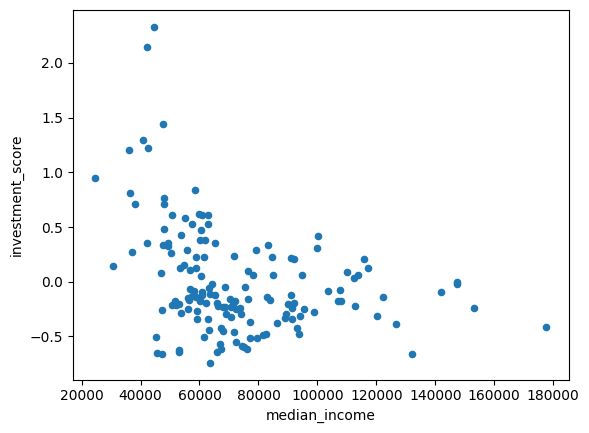

In [17]:
investment_df.plot.scatter(
    x="median_income",
    y="investment_score"
)

In [18]:
investment_df.to_csv("indiana_real_estate_investment.csv", index=False)

In [19]:
indiana_df = investment_df